In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.to_csv("diabetes_data.csv", index=False)

In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,4.278646,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.021516,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


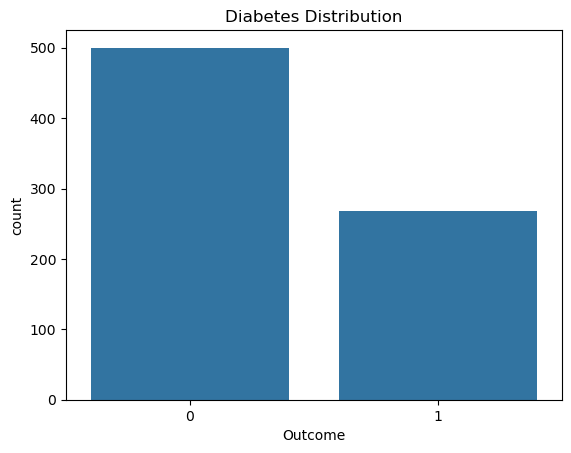

In [10]:
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Distribution")
plt.show()

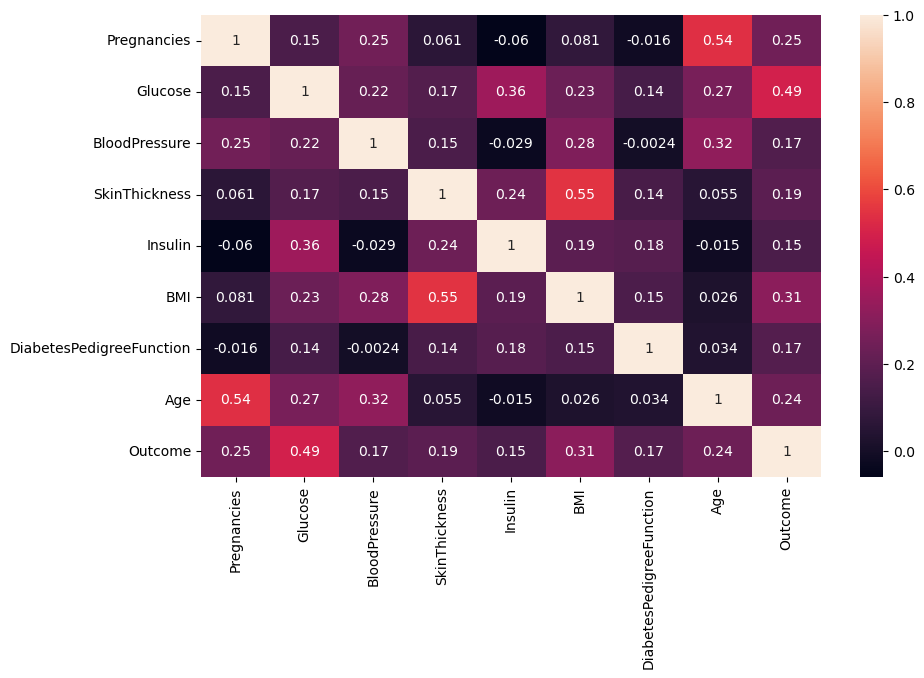

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

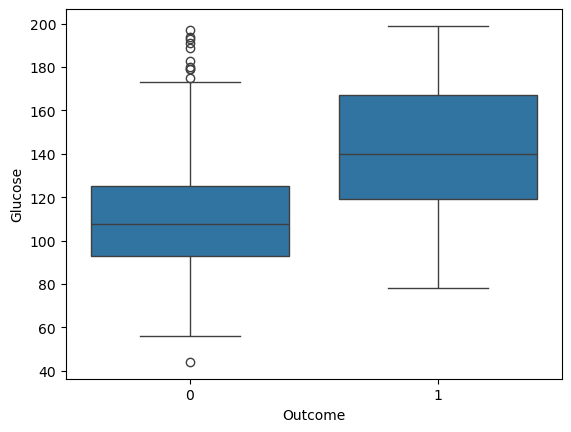

In [12]:
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.show()

In [13]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7532467532467533


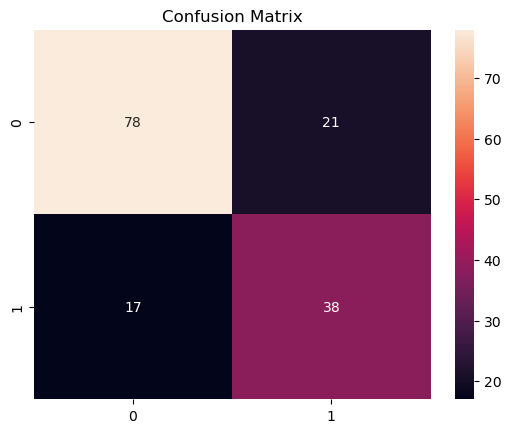

In [19]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.80        99
           1       0.64      0.69      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154



In [22]:
param_grid = {
    "n_estimators":[200],
    "max_depth":[8],
    "min_samples_split":[2]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 200}


In [23]:
best_model = grid.best_estimator_

In [24]:
joblib.dump(best_model,"diabetes_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [25]:
model = joblib.load("diabetes_model.pkl")
scaler = joblib.load("scaler.pkl")

In [ ]:
preg = int(input("Pregnancies: "))
glucose = int(input("Glucose: "))
bp = int(input("Blood Pressure: "))
skin = int(input("Skin Thickness: "))
insulin = int(input("Insulin: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = int(input("Age: "))

data = [[preg,glucose,bp,skin,insulin,bmi,dpf,age]]

data = scaler.transform(data)

prediction = model.predict(data)

if prediction[0] == 1:
    print("Person is likely to have diabetes")
else:
    print("Person is not diebetic")

print("Thank you!!!")